In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
plt.style.use("ggplot")

In [3]:
DB_USER = "postgres"
DB_PASSWORD = "usman123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "Adventureworks"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [5]:
monthly = pd.read_sql(
    "SELECT * FROM analytics.monthly_revenue",
    engine
)

territory = pd.read_sql(
    "SELECT * FROM analytics.regional_performance",
    engine
)

segments = pd.read_sql(
    "SELECT * FROM analytics.customer_segments",
    engine
)

products = pd.read_sql(
    "SELECT * FROM analytics.product_performance",
    engine
)

categories = pd.read_sql(
    "SELECT * FROM analytics.category_performance",
    engine
)

employees = pd.read_sql(
    "SELECT * FROM analytics.salesperson_performance",
    engine
)

inventory = pd.read_sql(
    "SELECT * FROM analytics.inventory_health",
    engine
)

kpi = pd.read_sql(
    "SELECT * FROM analytics.executive_kpi_dashboard",
    engine
)

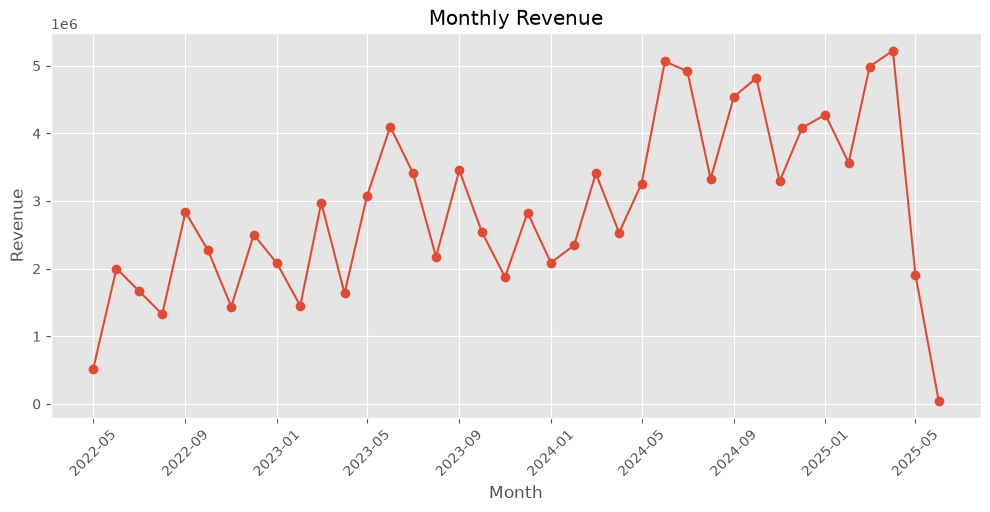

In [7]:
%matplotlib inline
from pathlib import Path
output_dir = Path(r"D:\Netixsol_Intern_Projects\Week-3\enterprise_analytics_hackathon\charts")
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12,5))

plt.plot(
    monthly["sales_month"],
    monthly["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.savefig(output_dir / "01_monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
The monthly revenue trend helps identify sales growth patterns, seasonal fluctuations, and periods of strong or weak business performance for better forecasting and planning.

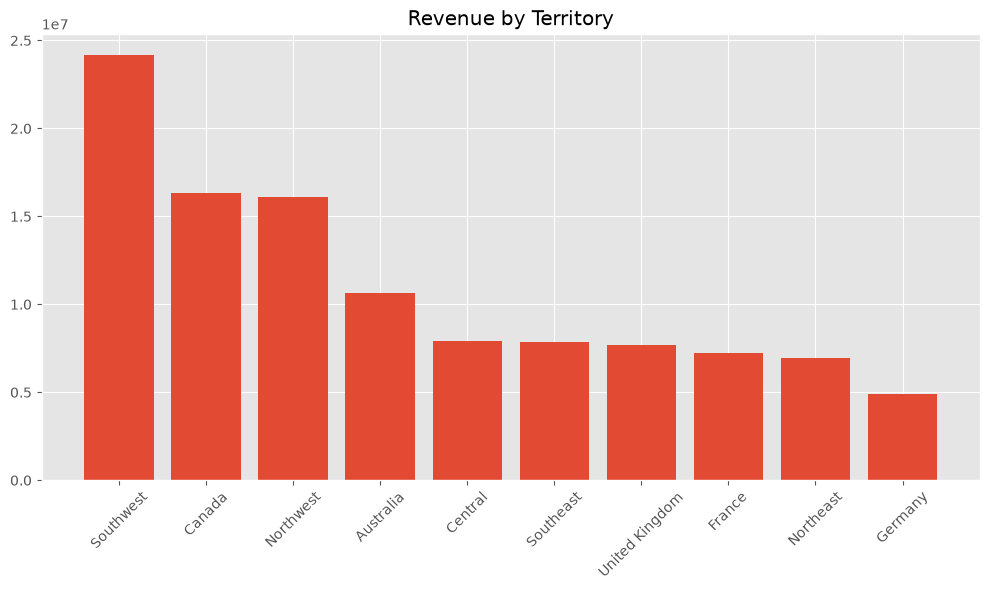

In [8]:
%matplotlib inline
territory = territory.sort_values("revenue", ascending=False)

plt.figure(figsize=(10,6))

plt.bar(
    territory["territory_name"],
    territory["revenue"]
)

plt.xticks(rotation=45)

plt.title("Revenue by Territory")
plt.tight_layout()
plt.savefig(output_dir / "02_revenue_by_territory.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
This chart compares revenue across different territories, helping management identify high-performing regions and areas that require additional sales and marketing efforts.

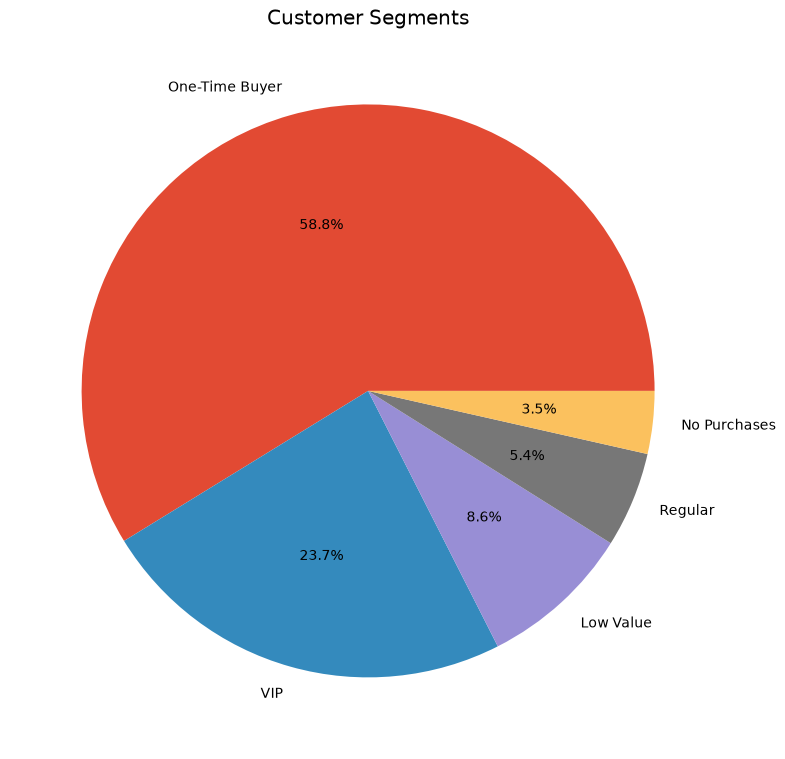

In [9]:
%matplotlib inline
segment_counts = segments["customer_segment"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Segments")
plt.tight_layout()
plt.savefig(output_dir / "03_customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
Customer segmentation shows the distribution of customers across different segments, enabling personalized marketing strategies and improved customer relationship management.

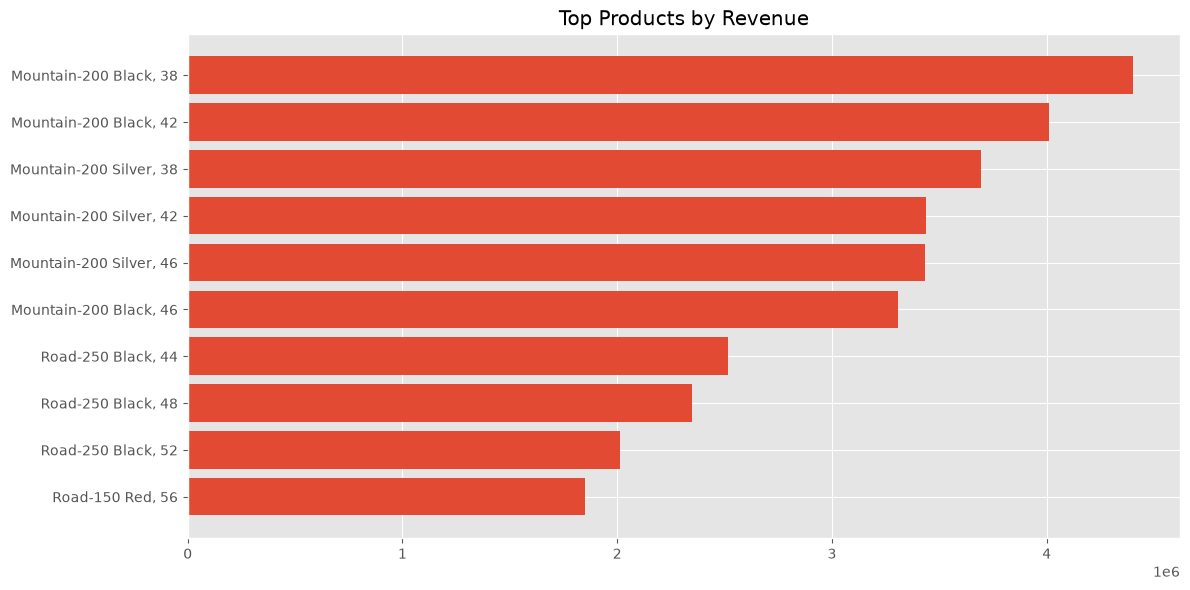

In [10]:
%matplotlib inline
top = products.nlargest(10,"revenue")

plt.figure(figsize=(12,6))

plt.barh(
    top["product_name"],
    top["revenue"]
)

plt.title("Top Products by Revenue")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / "04_top_products.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
Customer segmentation shows the distribution of customers across different segments, enabling personalized marketing strategies and improved customer relationship management.

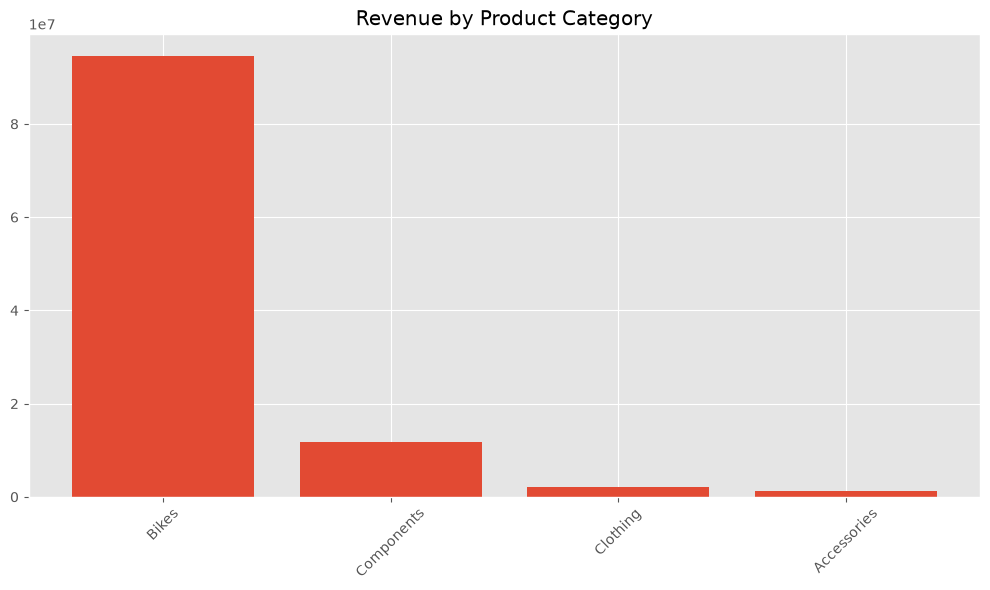

In [11]:
%matplotlib inline
plt.figure(figsize=(10,6))

plt.bar(
    categories["category_name"],
    categories["revenue"]
)

plt.xticks(rotation=45)

plt.title("Revenue by Product Category")
plt.tight_layout()
plt.savefig(output_dir / "05_category_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
The top-selling products generate the highest revenue and should receive priority in inventory management, promotions, and future business planning.

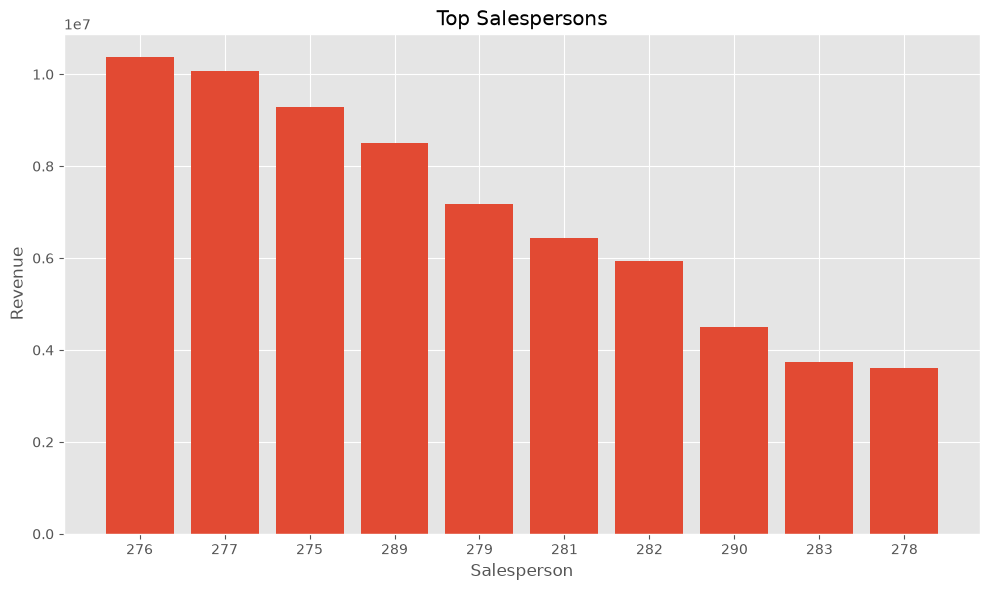

In [12]:
%matplotlib inline
top_emp = employees.sort_values(
    "revenue",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_emp["salespersonid"].astype(str),
    top_emp["revenue"]
)

plt.title("Top Salespersons")

plt.xlabel("Salesperson")

plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(output_dir / "06_top_salespersons.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
Salesperson performance identifies the highest revenue contributors, helping management design incentive programs and provide targeted training for lower-performing employees.

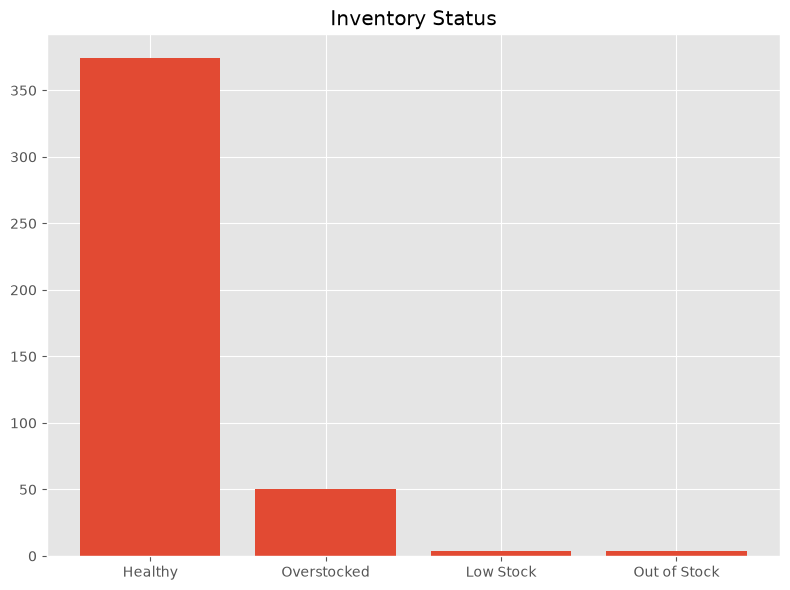

In [13]:
%matplotlib inline
inventory_count = inventory["stock_status"].value_counts()

plt.figure(figsize=(8,6))

plt.bar(
    inventory_count.index,
    inventory_count.values
)

plt.title("Inventory Status")
plt.tight_layout()
plt.savefig(output_dir / "07_inventory_status.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
Inventory status provides visibility into healthy, low-stock, and overstocked products, supporting efficient inventory planning and reducing stock-related risks.

In [15]:
%matplotlib inline
kpi = kpi.T.reset_index()

kpi.columns = ["Metric","Value"]

display(kpi)

,Metric,Value
0,total_revenue,109846381.399888
1,latest_month_revenue,47491.55
2,latest_mom_growth_pct,-97.51
3,latest_yoy_growth_pct,-54.18
4,total_customers,19820
5,vip_customers,4698
6,inactive_customers,701
7,avg_customer_ltv,5745.4
8,top_product,"Mountain-200 Black, 38"
9,top_territory,Southwest


### Business Insight
The executive KPI summary provides a consolidated overview of key business metrics, enabling executives to monitor overall organizational performance through a single dashboard.

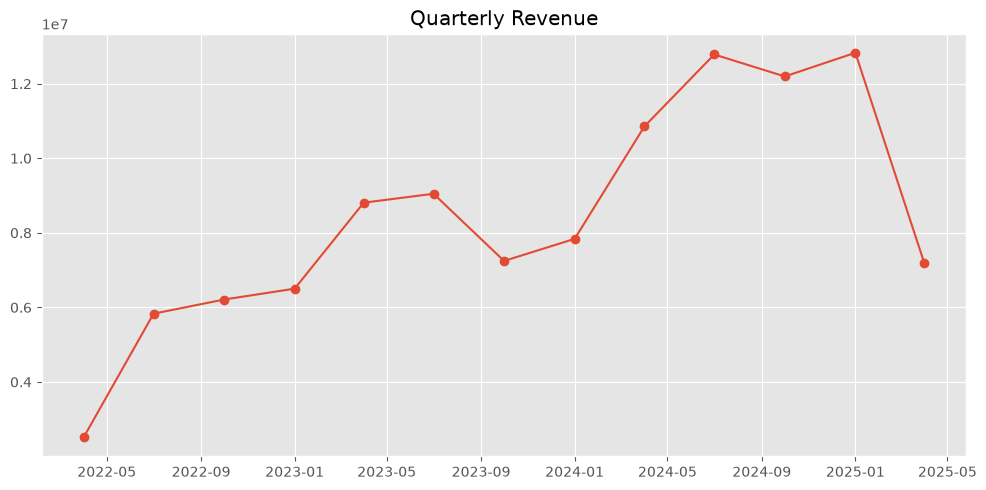

In [16]:
%matplotlib inline
quarter = pd.read_sql(
    "SELECT * FROM analytics.quarterly_revenue",
    engine
)

plt.figure(figsize=(10,5))

plt.plot(
    quarter["sales_quarter"],
    quarter["revenue"],
    marker="o"
)

plt.title("Quarterly Revenue")
plt.tight_layout()
plt.savefig(output_dir / "09_quarterly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
Quarterly revenue summarizes business performance over longer periods, helping management evaluate strategic growth trends and seasonal business performance.

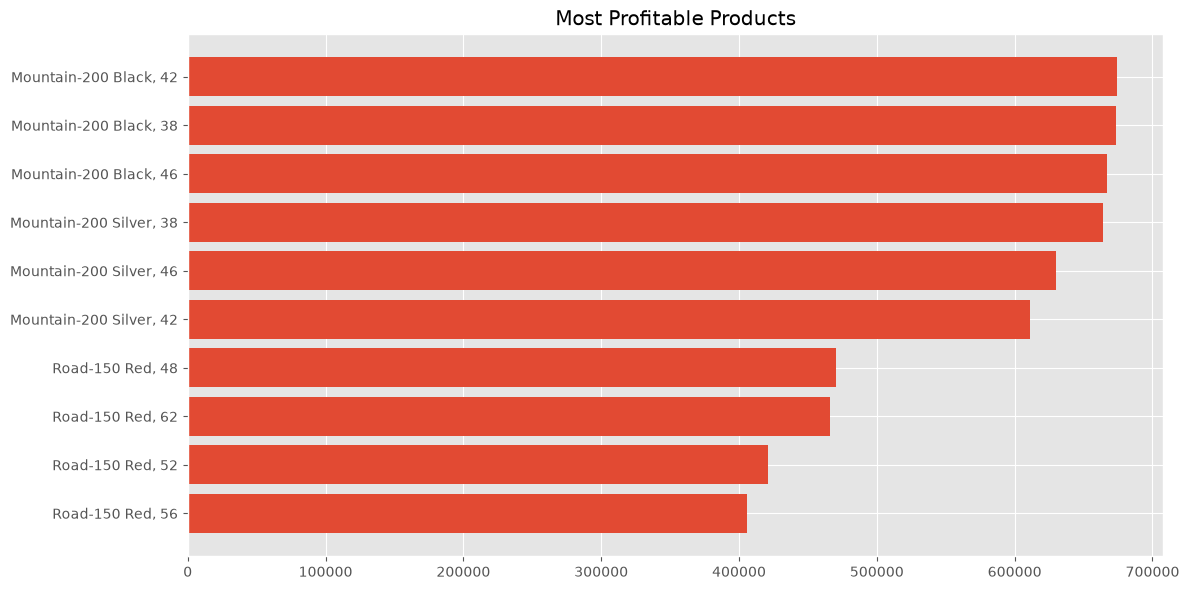

In [17]:
%matplotlib inline
profit = pd.read_sql(
    "SELECT * FROM analytics.product_profitability",
    engine
)

top = profit.nlargest(10,"estimated_profit")

plt.figure(figsize=(12,6))

plt.barh(
    top["product_name"],
    top["estimated_profit"]
)

plt.gca().invert_yaxis()

plt.title("Most Profitable Products")
plt.tight_layout()
plt.savefig(output_dir / "10_product_profitability.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight
Product profitability identifies products generating the highest estimated profit, supporting pricing strategies, inventory prioritization, and future product investment decisions.

# Business Opportunities

1. Expand marketing efforts in high-performing territories to maximize overall sales revenue.
2. Increase inventory for top-selling and highly profitable products to prevent stock shortages.
3. Develop loyalty programs for VIP and repeat customers to improve customer retention.
4. Promote high-performing product categories through targeted advertising campaigns.
5. Strengthen partnerships with high-performing suppliers to improve procurement efficiency and product availability.

# Business Risks

1. Dependence on a limited number of high-performing territories may increase business risk.
2. Low-performing products can reduce profitability and increase inventory holding costs.
3. Customer attrition may negatively impact long-term revenue growth.
4. Underperforming salespersons may reduce overall sales productivity.
5. Low-stock and out-of-stock products may lead to lost sales opportunities and lower customer satisfaction.

# Actionable Recommendations

1. Allocate additional sales and marketing resources to the highest-performing territories.
2. Implement automated inventory monitoring to maintain optimal stock levels.
3. Launch customer loyalty and retention programs targeting VIP and repeat customers.
4. Provide performance-based incentives and training programs for sales employees.
5. Continuously monitor supplier quality and procurement trends to improve supply chain performance.